# SCVI short template
This is a small python notebook I wrote, mostly adapted from the SCVI tutorial, stripped down so I can load my data as needed.

Notes: Ensure CUDA support - this hopefully will make the analysis much faster
## Load dependencies

In [1]:
# load the dependencies
import scanpy as sc
import scvi
import anndata as ad
import pandas as pd
import numpy as np

# Using tensor cores for precision
#torch.set_float32_matmul_precision('medium' | 'high')

## Load the counts
Use the below code block to load in the count matrix as needed.
Ensure the appropriate metadata file is also loaded.

In [2]:
# Load the counts
#counts = pd.read_csv("raw_counts.txt", index_col=0, sep="\t")

# metadata with batch info
#meta = pd.read_table("meta.csv", index_col=0,sep="\t")


counts = counts.reindex(columns=list(meta.index), fill_value=0)

adata = ad.AnnData(
    X=counts.T,          # scVI expects cells x genes
    obs=meta
)


## Basic filtering
Applying some basic filtering before running the model.
Right now using the thresholds as mentioned in the DESeq2 vignette, but you do you.

In [3]:
# Filter based on DESeq2 thresholds
X = adata.X

# Count how many samples have >= 5 counts per gene
gene_mask = np.asarray((X >= 5).sum(axis=0)).ravel() >= 3
gene_mask.sum()
adata = adata[:, gene_mask].copy()
adata.n_vars


1908

## HVG
Calculate the highly variable genes, lets one know which genes are actually informative

In [4]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3",
)
adata = adata[:, adata.var["highly_variable"]].copy()


## Create SCVI object
Loads the count file. If there is any batch information, modify the _batch_key_ variable as required

In [5]:
scvi.model.SCVI.setup_anndata(
    adata
#    batch_key="batch"   # column in adata.obs
)
adata

AnnData object with n_obs × n_vars = 72 × 1908
    obs: 'Age', 'hCG_Result', 'Pregnancy_result', 'type_old', 'G1', 'G2', 'G3', 'parental_code', 'Method', 'type', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid'

## Run the SCVI model
This is the main step nthat runs the model.
Tune the gene_likelihood, or other parameters as required

In [6]:
# Register scvi.model.SCVI.setup_anndata(adata)
model = scvi.model.SCVI(
    adata,
    n_latent=30,        # typical: 20–50
    gene_likelihood="zinb"
)

model.train(
    max_epochs=400,
    early_stopping=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/user/scvi_requirements/lib/python3.12/site-packages/torch/__init__.py:1539: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for 

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 4196.543. Signaling Trainer to stop.


## Some visualizations

In [7]:
adata.obsm["X_scVI"] = model.get_latent_representation()

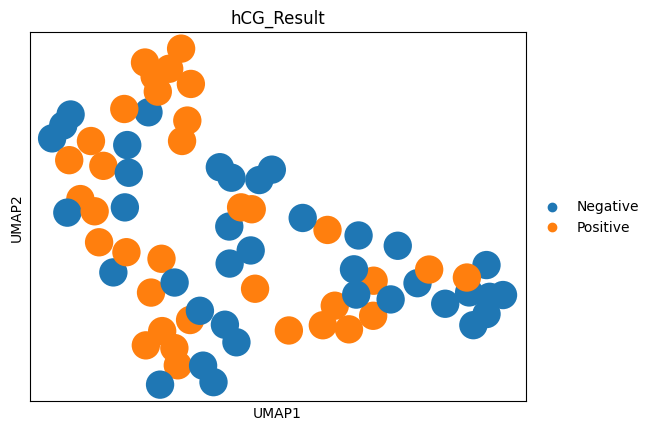

In [8]:
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["hCG_Result"])


<Axes: xlabel='epoch'>

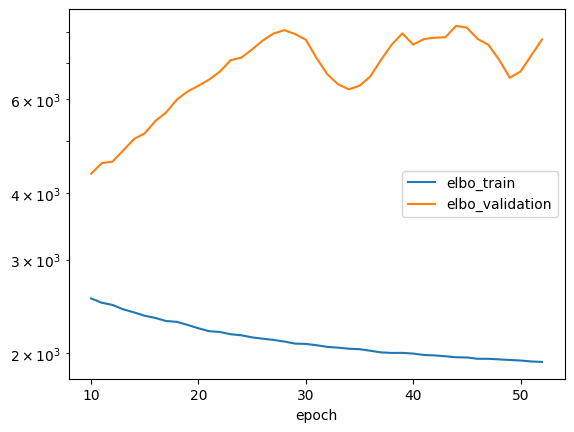

In [9]:
train_test_results = model.history["elbo_train"]
train_test_results["elbo_validation"] = model.history["elbo_validation"]
train_test_results.iloc[10:].plot(logy=True)  # exclude first 10 epochs

In [10]:
# get total number of samples to compare
adata.obs["hCG_Result"].value_counts()

hCG_Result
Negative    37
Positive    35
Name: count, dtype: int64

## DEGs
The below code is to perform basic DEG analysis from the latent embedding. Ensure you have enough cells to actually perform the analysis

In [11]:
cell_idx1 = adata.obs["hCG_Result"] == "Negative"
cell_idx2 = adata.obs["hCG_Result"] == "Positive"
de_change = model.differential_expression(idx1=cell_idx1, idx2=cell_idx2, mode="change")
de_change

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
gene_id,,,,,,,,,,,,,,,,,,,
ENSG00000281383.1,0.6062,0.3938,0.431367,0.003752,0.005258,5.784348e-07,0.25,-0.716613,-0.646214,1.482899,-5.813604,4.279198,888.378378,827.485714,1.000000,1.000000,3169.160985,3965.541299,False
ENSG00000274585.1,0.5916,0.4084,0.370584,0.000764,0.001045,5.784348e-07,0.25,-2.044380,-0.803245,5.768729,-15.006714,13.220895,1.783784,2.314286,0.648649,0.514286,9.322713,18.536892,False
ENSG00000184357.5,0.5872,0.4128,0.352402,0.000593,0.000854,5.784348e-07,0.25,-1.874296,-0.753339,4.323338,-11.382638,9.674204,1.162162,2.514286,0.297297,0.428571,2.249087,8.289262,False
ENSG00000206585.1,0.5862,0.4138,0.348278,0.000486,0.000676,5.784348e-07,0.25,-1.537797,-0.693267,4.402703,-10.488413,10.351350,1.891892,1.142857,0.756757,0.485714,8.947402,4.723678,False
ENSG00000281181.1,0.5812,0.4188,0.327701,0.001404,0.001849,5.784348e-07,0.25,-0.789179,-0.530230,1.842718,-5.733892,4.959738,6.972973,6.914286,0.918919,0.800000,24.855956,27.399358,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000149273.15,0.3484,0.6516,-0.626080,0.001425,0.001374,5.784348e-07,0.25,0.039263,0.040756,0.575897,-2.089183,1.707668,16.567568,4.457143,0.810811,0.571429,16.457395,10.943726,False
ENSG00000115268.10,0.3480,0.6520,-0.627842,0.000922,0.000910,5.784348e-07,0.25,0.011407,0.019613,0.631195,-2.061388,2.115494,9.810811,3.514286,0.648649,0.571429,9.473806,14.273338,False
ENSG00000122026.11,0.3480,0.6520,-0.627842,0.001078,0.001078,5.784348e-07,0.25,-0.002405,0.022895,0.610367,-2.112590,2.144422,16.135135,5.314286,0.756757,0.485714,14.278042,12.422005,False


In [12]:
de_change_uniform = model.differential_expression(
    idx1=cell_idx1,  # we use the same cells as chosen before
    idx2=cell_idx2,
    weights="uniform",
    mode="change"
)
de_change_uniform["log10_pscore"] = np.log10(de_change_uniform["proba_not_de"])
de_change_uniform = de_change_uniform.join(adata.var, how="inner")
de_change_uniform.head()


DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,log10_pscore,highly_variable,highly_variable_rank,means,variances,variances_norm
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000184357.5,0.6140,0.3860,0.464158,0.000585,0.000874,6.212177e-07,0.25,-2.038810,-0.893949,4.229278,...,0.428571,2.249087,8.289262,False,-0.413413,True,572.0,1.819444,20.150039,1.138659
ENSG00000281383.1,0.6110,0.3890,0.451518,0.003726,0.005239,6.212177e-07,0.25,-0.736735,-0.656756,1.464254,...,1.000000,3169.160985,3965.541299,False,-0.410050,True,1830.0,858.777778,445922.851330,0.570806
ENSG00000274585.1,0.6048,0.3952,0.425506,0.000743,0.001069,6.212177e-07,0.25,-2.279192,-0.933292,5.657940,...,0.514286,9.322713,18.536892,False,-0.403183,True,1889.0,2.041667,10.040493,0.445561
ENSG00000104979.9,0.6028,0.3972,0.417146,0.000512,0.000734,6.212177e-07,0.25,-1.345965,-0.824603,3.200489,...,0.142857,2.983236,19.971567,False,-0.400991,True,1515.0,1.319444,8.079617,0.756133
ENSG00000131504.18,0.6014,0.3986,0.411302,0.000326,0.000474,6.212177e-07,0.25,-2.060221,-0.768153,5.129356,...,0.228571,1.525401,2.793827,False,-0.399463,True,1034.0,0.763889,3.760368,0.939818
